In [23]:
import json
import matplotlib.pyplot as plt
import pandas as pd


In [24]:
entsoe_timeseries_df = pd.read_csv("../datasets/ENTSOE_power_time_series.csv", index_col=0, parse_dates=True)
with open("../datasets/metadata_wind_farms.json") as f:
    wind_farms_metadata = json.load(f)["wind_farms"]

In [28]:
wind_farm_id_list = [wf["id"] for wf in wind_farms_metadata if wf.get("offshore_data_available") is True]
print(wind_farm_id_list)

['Borssele_12', 'Borssele_34', 'Gemini', 'Hollandse_Kust_Zuid', 'Hollandse_Kust_Noord']


In [19]:
df_nearest_KNMI_stations = {}
for wind_farm in wind_farms_metadata:
    station = wind_farm.get("nearest_KNMI_station")
    try:
        df = pd.read_csv("../datasets/KNMI_by_station_2015plus/knmi_"+station+"_2015plus_preprocessed.csv")
        df_nearest_KNMI_stations[wind_farm['id']] = df
    except:
        print(f"No file found for station {station} needed for {wind_farm['id']}")

No file found for station None needed for Windfarm_Princess_Amalia
No file found for station None needed for OWEZ


In [ ]:
def predict_power(wind_speed, popt, cut_out=25.0):
    p = piecewise_logistic(wind_speed, *popt)
    p = np.where(wind_speed >= cut_out, 0, p)  # cut-out
    p = np.where(wind_speed < 3, 0, p)          # cut-in (optional)
    p = np.maximum(p, 0)                         # no negative power
    return p

In [30]:
windspeed_scaling_for_platform_height = 1.034

df_nearest_KNMI_stations["Borssele_12"]["predicted_power"] = predict_power(df_nearest_KNMI_stations["Borssele_12"]["wind_speed"].values * windspeed_scaling_for_platform_height, popt)

0         7.0
1         7.0
2         7.0
3         7.0
4         7.0
         ... 
100075    3.0
100076    3.0
100077    2.0
100078    3.0
100079    4.0
Name: wind_speed_ms, Length: 100080, dtype: float64

In [39]:
df = pd.read_csv("../datasets/offshore_Borssele_12.csv")

C:\Users\lackn\AppData\Local\Temp\ipykernel_35796\3270904258.py:7: RuntimeWarning: overflow encountered in power
  return alpha / (1 + np.exp(-gamma * (v - delta))) ** (1 / beta)
C:\Users\lackn\AppData\Local\Temp\ipykernel_35796\3270904258.py:7: RuntimeWarning: overflow encountered in exp
  return alpha / (1 + np.exp(-gamma * (v - delta))) ** (1 / beta)
C:\Users\lackn\AppData\Local\Temp\ipykernel_35796\3270904258.py:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


Fitted parameters:
alpha1=-2128378.948, beta1=33913705.428, gamma1=-643188705.742, delta1=-2032356396.615
alpha2=686.030, beta2=-0.264, gamma2=4.244, delta2=-19.066
tau=9.000


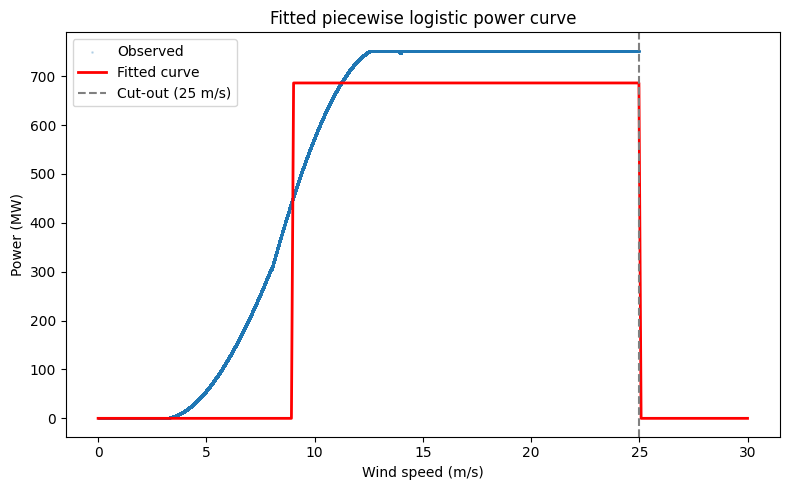

In [52]:
#fitting power curves
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def logistic_piece(v, alpha, beta, gamma, delta):
    return alpha / (1 + np.exp(-gamma * (v - delta))) ** (1 / beta)

def piecewise_logistic(v, alpha1, beta1, gamma1, delta1, alpha2, beta2, gamma2, delta2, tau):
    return np.where(
        v < tau,
        logistic_piece(v, alpha1, beta1, gamma1, delta1),
        logistic_piece(v, alpha2, beta2, gamma2, delta2)
    )

# --- fit ---
# drop rows where turbine is off or wind speed is 0
fit_df = df[(df["Turn_off"] == 1) & (df["Scaled_Windspeed"] > 0)].copy()

v = fit_df["Scaled_Windspeed"].values
p = fit_df["Power"].values

# initial guesses based on the paper's values
p0 = [
    0.001,   # alpha1
    0.023,   # beta1
    -0.128,  # gamma1
    0.143,   # delta1
    0.005,   # alpha2
    -0.264,  # beta2
    4.244,   # gamma2
    -19.066, # delta2
    9.0      # tau
]

popt, pcov = curve_fit(
    piecewise_logistic,
    v, p,
    p0=p0,
    maxfev=10000
)

print("Fitted parameters:")
print(f"alpha1={popt[0]:.3f}, beta1={popt[1]:.3f}, gamma1={popt[2]:.3f}, delta1={popt[3]:.3f}")
print(f"alpha2={popt[4]:.3f}, beta2={popt[5]:.3f}, gamma2={popt[6]:.3f}, delta2={popt[7]:.3f}")
print(f"tau={popt[8]:.3f}")

# --- apply cut-out at 25 m/s ---
v_range = np.linspace(0, 30, 300)
p_fitted = np.where(
    v_range <= 25,
    piecewise_logistic(v_range, *popt),
    0
)

# --- plot ---
plt.figure(figsize=(8, 5))
plt.scatter(v, p, s=1, alpha=0.2, label="Observed")
plt.plot(v_range, p_fitted, color="red", linewidth=2, label="Fitted curve")
plt.axvline(25, color="gray", linestyle="--", label="Cut-out (25 m/s)")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power (MW)")
plt.title("Fitted piecewise logistic power curve")
plt.legend()
plt.tight_layout()
plt.show()

Fitted parameters:
alpha=760.961, beta=1.333, gamma=0.829, delta=8.983


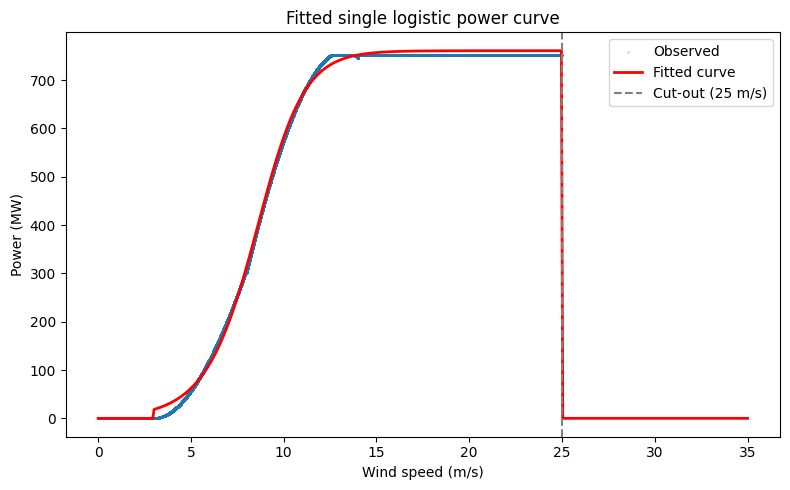

In [53]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def single_logistic(v, alpha, beta, gamma, delta):
    return alpha / (1 + np.exp(-gamma * (v - delta))) ** (1 / beta)

def predict_power(wind_speed, popt, cut_in=3.0, cut_out=25.0):
    p = single_logistic(wind_speed, *popt)
    p = np.where(wind_speed >= cut_out, 0, p)
    p = np.where(wind_speed < cut_in, 0, p)
    p = np.maximum(p, 0)
    return p

# --- prep data ---
fit_df = df[(df["Turn_off"] == 1) & (df["Scaled_Windspeed"] > 0)].copy()

v = fit_df["Scaled_Windspeed"].values
p = fit_df["Power"].values

# --- fit ---
p0 = [
    p.max(),  # alpha: rated power
    1.0,      # beta
    1.0,      # gamma: steepness
    10.0      # delta: inflection point
]

popt, pcov = curve_fit(
    single_logistic,
    v, p,
    p0=p0,
    bounds=(
        [0,    0.01, 0,    0  ],
        [np.inf, 10, 10, 30  ]
    ),
    maxfev=10000
)

print("Fitted parameters:")
print(f"alpha={popt[0]:.3f}, beta={popt[1]:.3f}, gamma={popt[2]:.3f}, delta={popt[3]:.3f}")

# --- plot ---
v_range = np.linspace(0, 35, 500)
p_fitted = predict_power(v_range, popt)

plt.figure(figsize=(8, 5))
plt.scatter(v, p, s=1, alpha=0.2, label="Observed")
plt.plot(v_range, p_fitted, color="red", linewidth=2, label="Fitted curve")
plt.axvline(25, color="gray", linestyle="--", label="Cut-out (25 m/s)")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power (MW)")
plt.title("Fitted single logistic power curve")
plt.legend()
plt.tight_layout()
plt.show()

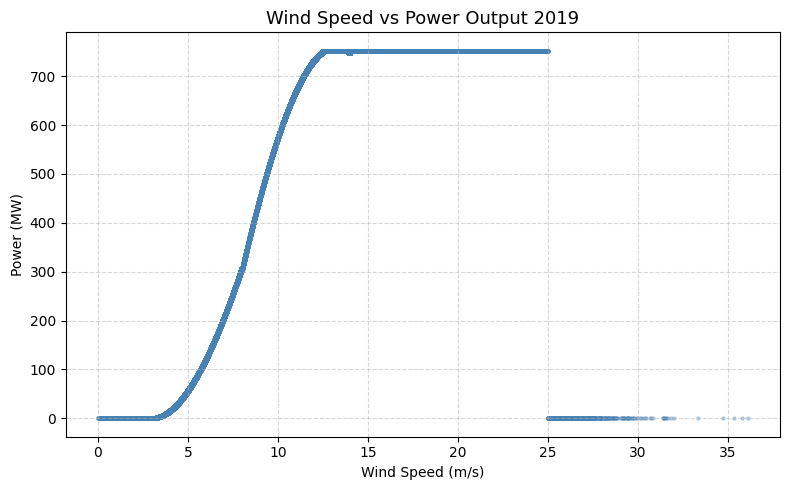

In [38]:
df = pd.read_csv("../datasets/offshore_Borssele_12.csv")
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['Scaled_Windspeed'], df['Power'], alpha=0.3, s=5, color='steelblue')
ax.set_title('Wind Speed vs Power Output 2019', fontsize=13)
ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Power (MW)')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
def predict_power(wind_speed, popt, cut_out=25.0):
    p = piecewise_logistic(wind_speed, *popt)
    p = np.where(wind_speed >= cut_out, 0, p)  # cut-out
    p = np.where(wind_speed < 3, 0, p)          # cut-in (optional)
    p = np.maximum(p, 0)                         # no negative power
    return p

# single value
predict_power(8.5, popt)

# array / dataframe column
df["Power_predicted"] = predict_power(df["Scaled_Windspeed"].values, popt)